In [1]:
import pandas as pd
import numpy as np

In [2]:
import glob

csv_files = glob.glob("/content/*.csv")

print("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:


In [3]:
file_path = csv_files[0]

df = pd.read_csv(file_path, encoding="latin-1")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

IndexError: list index out of range

In [4]:
import os

print(os.listdir("/content"))

['.config', 'sample_data']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [5]:
import os

print(os.listdir("/content"))

['.config', 'sample_data']


In [6]:
import pandas as pd
import numpy as np

file_path = "/DataCoSupplyChainDataset.csv.csv"

df = pd.read_csv(file_path, encoding="latin-1")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 180519
Columns: 53


In [7]:
print(df.columns.tolist())


['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrde

In [8]:
print(df["Late_delivery_risk"].value_counts())
print()
print(df["Late_delivery_risk"].value_counts(normalize=True) * 100)

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64


In [9]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0].sort_values(ascending=False))

Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64


In [10]:
columns_to_drop = [
    "Product Description",
    "Order Zipcode",
    "Customer Lname",
    "Customer Zipcode"
]

df = df.drop(columns=columns_to_drop)

print("Columns remaining:", df.shape[1])

Columns remaining: 49


In [11]:
leakage_columns = [
    "Delivery Status",
    "Days for shipping (real)",
    "Order Status"
]

df = df.drop(columns=leakage_columns)

print("Columns remaining:", df.shape[1])

Columns remaining: 46


In [12]:
X = df.drop(columns=["Late_delivery_risk"])
y = df["Late_delivery_risk"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (180519, 45)
y shape: (180519,)


In [13]:
print("Numerical columns:")
print(X.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical columns:")
print(X.select_dtypes(include="object").columns.tolist())

Numerical columns:
['Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Category Id', 'Customer Id', 'Department Id', 'Latitude', 'Longitude', 'Order Customer Id', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Card Id', 'Product Category Id', 'Product Price', 'Product Status']

Categorical columns:
['Type', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Region', 'Order State', 'Product Image', 'Product Name', 'shipping date (DateOrders)', 'Shipping Mode']


In [14]:
columns_to_drop = [
    "Customer Email",
    "Customer Fname",
    "Customer Password",
    "Customer Street",
    "Product Image",
    "Order Id",
    "Order Item Id",
    "Customer Id",
    "Order Customer Id"
]

X = X.drop(columns=columns_to_drop)

print("Remaining predictor columns:", X.shape[1])

Remaining predictor columns: 36


In [18]:
X["order_date"] = pd.to_datetime(
    X["order date (DateOrders)"],
    errors="coerce"
)

X["order_year"] = X["order_date"].dt.year
X["order_month"] = X["order_date"].dt.month
X["order_dayofweek"] = X["order_date"].dt.dayofweek
X["order_hour"] = X["order_date"].dt.hour

In [19]:
X["shipping_date"] = pd.to_datetime(
    X["shipping date (DateOrders)"],
    errors="coerce"
)

X["shipping_year"] = X["shipping_date"].dt.year
X["shipping_month"] = X["shipping_date"].dt.month
X["shipping_dayofweek"] = X["shipping_date"].dt.dayofweek

In [20]:
X = X.drop(columns=[
    "order date (DateOrders)",
    "shipping date (DateOrders)",
    "order_date",
    "shipping_date"
])

print("Predictor columns:", X.shape[1])

Predictor columns: 41


In [21]:
categorical_columns = X.select_dtypes(include="object").columns

for col in categorical_columns:
    print(col, "→", X[col].nunique(), "unique values")

Type → 4 unique values
Category Name → 50 unique values
Customer City → 563 unique values
Customer Country → 2 unique values
Customer Segment → 3 unique values
Customer State → 46 unique values
Department Name → 11 unique values
Market → 5 unique values
Order City → 3597 unique values
Order Country → 164 unique values
Order Region → 23 unique values
Order State → 1089 unique values
Product Name → 118 unique values
Shipping Mode → 4 unique values


In [22]:
columns_to_drop = [
    "Customer City",
    "Order City",
    "Order Country",
    "Order State"
]

X = X.drop(columns=columns_to_drop)

print("Remaining predictor columns:", X.shape[1])

Remaining predictor columns: 37


In [23]:
numerical_columns = X.select_dtypes(include=np.number).columns

for col in numerical_columns:
    print(col, "→", X[col].nunique(), "unique values")

Days for shipment (scheduled) → 4 unique values
Benefit per order → 21998 unique values
Sales per customer → 2927 unique values
Category Id → 51 unique values
Department Id → 11 unique values
Latitude → 11250 unique values
Longitude → 4487 unique values
Order Item Cardprod Id → 118 unique values
Order Item Discount → 1017 unique values
Order Item Discount Rate → 18 unique values
Order Item Product Price → 75 unique values
Order Item Profit Ratio → 162 unique values
Order Item Quantity → 5 unique values
Sales → 193 unique values
Order Item Total → 2927 unique values
Order Profit Per Order → 21998 unique values
Product Card Id → 118 unique values
Product Category Id → 51 unique values
Product Price → 75 unique values
Product Status → 1 unique values
order_year → 4 unique values
order_month → 12 unique values
order_dayofweek → 7 unique values
order_hour → 24 unique values
shipping_year → 4 unique values
shipping_month → 12 unique values
shipping_dayofweek → 7 unique values


In [24]:
X = X.drop(columns=["Product Status"])

print("Predictor columns:", X.shape[1])

Predictor columns: 36


In [25]:
id_columns = [
    "Order Item Cardprod Id",
    "Product Card Id",
    "Product Category Id",
    "Category Id",
    "Department Id"
]

X = X.drop(columns=id_columns)

print("Predictor columns:", X.shape[1])

Predictor columns: 31


In [26]:
categorical_columns = X.select_dtypes(include="object").columns

print("Categorical columns:")
for col in categorical_columns:
    print("-", col)

Categorical columns:
- Type
- Category Name
- Customer Country
- Customer Segment
- Customer State
- Department Name
- Market
- Order Region
- Product Name
- Shipping Mode


In [27]:
categorical_columns = X.select_dtypes(include="object").columns.tolist()
numerical_columns = X.select_dtypes(include=np.number).columns.tolist()

print("Number of numerical columns:", len(numerical_columns))
print("Number of categorical columns:", len(categorical_columns))

Number of numerical columns: 21
Number of categorical columns: 10


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (144415, 31)
Testing data: (36104, 31)


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

print("Logistic Regression model created successfully!")

Logistic Regression model created successfully!


In [31]:
print("Training Logistic Regression...")

logistic_model.fit(X_train, y_train)

print("Training completed successfully!")

Training Logistic Regression...
Training completed successfully!


In [32]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 36104


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.7135
Precision: 0.8123
Recall   : 0.6209
F1-score : 0.7038
ROC-AUC  : 0.7586


In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print("----------------")
print(cm)

Confusion Matrix
----------------
[[13467  2841]
 [ 7504 12292]]


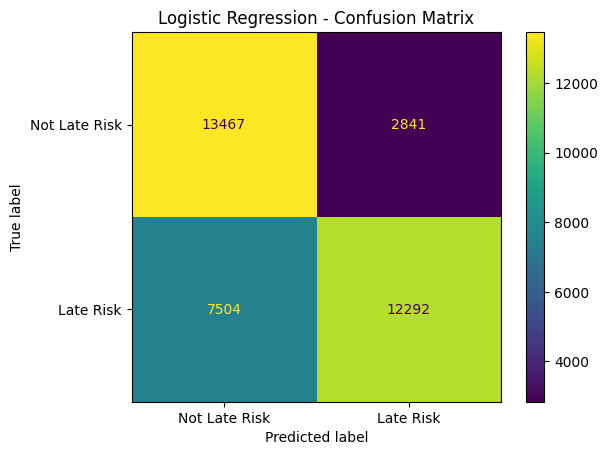

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Late Risk", "Late Risk"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [36]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("5-Fold ROC-AUC Scores:")
print(cv_scores)

print("\nMean ROC-AUC:", round(cv_scores.mean(), 4))
print("Standard Deviation:", round(cv_scores.std(), 4))

5-Fold ROC-AUC Scores:
[0.75494592 0.75608034 0.75266727 0.75774625 0.76156046]

Mean ROC-AUC: 0.7566
Standard Deviation: 0.003


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=50,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Faster Random Forest model created successfully!")

Faster Random Forest model created successfully!


In [42]:
print("Training Random Forest...")

random_forest_model.fit(X_train, y_train)

print("Random Forest training completed successfully!")

Training Random Forest...
Random Forest training completed successfully!


In [43]:
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

Random Forest Results
---------------------
Accuracy : 0.8179
Precision: 0.887
Recall   : 0.7655
F1-score : 0.8218
ROC-AUC  : 0.9225


In [44]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [10, 20]
}

grid_search = GridSearchCV(
    random_forest_model,
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

print("Starting hyperparameter tuning...")

grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed!")
print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 4))

Starting hyperparameter tuning...
Hyperparameter tuning completed!
Best parameters: {'classifier__max_depth': 20, 'classifier__n_estimators': 100}
Best CV ROC-AUC: 0.8859


In [45]:
best_model = grid_search.best_estimator_

tuned_pred = best_model.predict(X_test)
tuned_prob = best_model.predict_proba(X_test)[:, 1]

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred)
tuned_recall = recall_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred)
tuned_roc_auc = roc_auc_score(y_test, tuned_prob)

print("Tuned Random Forest Results")
print("---------------------------")
print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1-score :", round(tuned_f1, 4))
print("ROC-AUC  :", round(tuned_roc_auc, 4))

Tuned Random Forest Results
---------------------------
Accuracy : 0.7253
Precision: 0.8589
Recall   : 0.597
F1-score : 0.7044
ROC-AUC  : 0.9034
